In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [40]:
%cd /content/drive/MyDrive/Eco_Vision

/content/drive/MyDrive/Eco_Vision


In [41]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [42]:
DATASET_PATH = "/content/drive/MyDrive/Eco_Vision/Garbage_classification"

IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 10

In [43]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

test_data = datagen.flow_from_directory(
    DATASET_PATH,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

NUM_CLASSES = train_data.num_classes
print("Classes:", train_data.class_indices)

Found 2805 images belonging to 7 classes.
Found 700 images belonging to 7 classes.
Classes: {'battery': 0, 'cardboard': 1, 'glass': 2, 'metal': 3, 'paper': 4, 'plastic': 5, 'trash': 6}


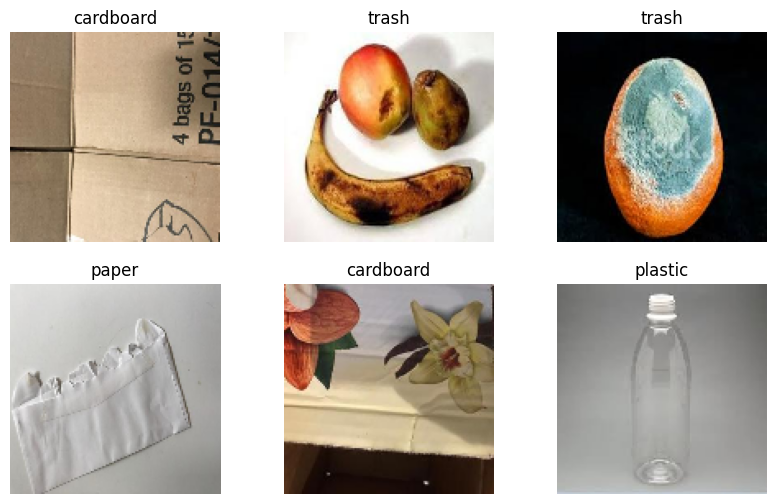

In [45]:
images, labels = next(train_data)

plt.figure(figsize=(10, 6))
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i])
    plt.title(list(train_data.class_indices.keys())[np.argmax(labels[i])])
    plt.axis("off")
plt.show()

In [46]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,393,223 (28.20 MB)

 Trainable params: 7,393,223 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [47]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=EPOCHS
)

Epoch 1/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 1824s 21s/step - accuracy: 0.2624 - loss: 2.1198 - val_accuracy: 0.4786 - val_loss: 1.3711
Epoch 2/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 96s 1s/step - accuracy: 0.5533 - loss: 1.2768 - val_accuracy: 0.5386 - val_loss: 1.2915
Epoch 3/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.6172 - loss: 1.0749 - val_accuracy: 0.5443 - val_loss: 1.2589
Epoch 4/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.6933 - loss: 0.8746 - val_accuracy: 0.5643 - val_loss: 1.2423
Epoch 5/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 146s 1s/step - accuracy: 0.7642 - loss: 0.6862 - val_accuracy: 0.5800 - val_loss: 1.2128
Epoch 6/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.8015 - loss: 0.5591 - val_accuracy: 0.5743 - val_loss: 1.2560
Epoch 7/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 98s 1s/step - accuracy: 0.8513 - loss: 0.4206 - val_accuracy: 0.5757 - val_loss: 1.4588
Epoch 8/10
88/88 ━━━━━━━━━━━━━━━━━━━━ 100s 1s/step - accuracy: 0.8687 - loss: 0.3893 - val_accuracy: 0.5886 - val

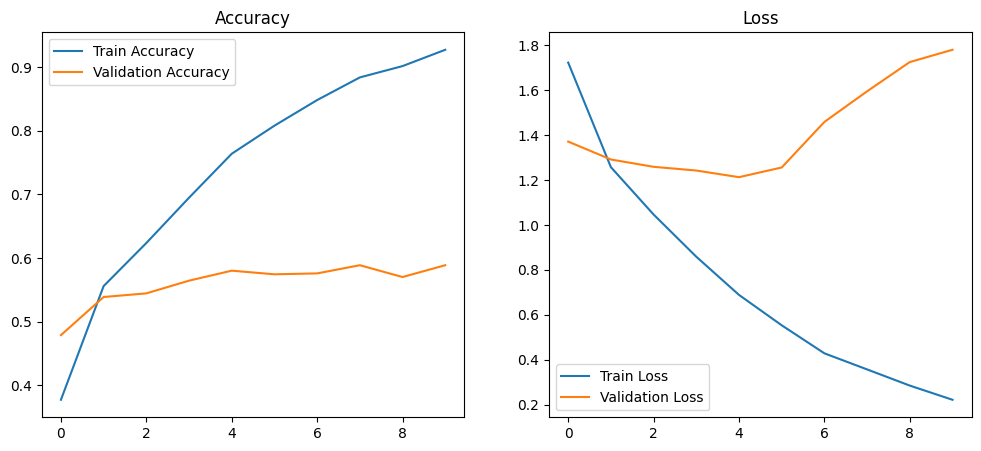

In [48]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")

plt.show()

In [58]:
test_loss, test_accuracy = model.evaluate(test_data)
print("Test Accuracy:", test_accuracy)

22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 407ms/step - accuracy: 0.6118 - loss: 1.8052
Test Accuracy: 0.5885714292526245


22/22 ━━━━━━━━━━━━━━━━━━━━ 9s 417ms/step


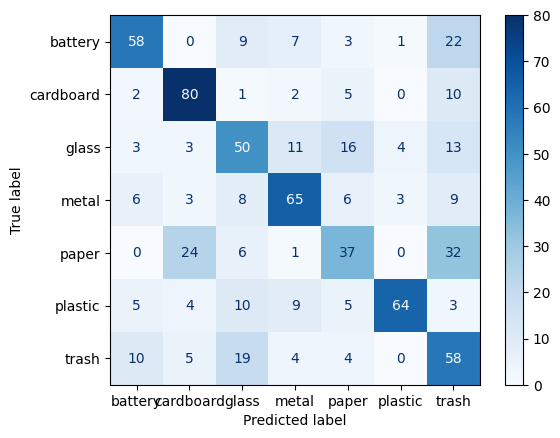

In [59]:
predictions = model.predict(test_data)
y_pred = np.argmax(predictions, axis=1)
y_true = test_data.classes

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=test_data.class_indices.keys())
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [62]:
MODEL_PATH = "/content/drive/MyDrive/Eco_Vision/ecovision_cnn_model.keras"
model.save(MODEL_PATH)

print("Model saved at:", MODEL_PATH)

Model saved at: /content/drive/MyDrive/Eco_Vision/ecovision_cnn_model.keras
